<a href="https://colab.research.google.com/github/deartoms/python/blob/main/Chapter05_03_%EC%9E%90%EC%A0%84%EA%B1%B0%EC%88%98%EC%9A%94%EC%98%88%EC%B8%A1%EC%8B%A4%EC%8A%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive


Saving NanumGothic.ttf to NanumGothic.ttf


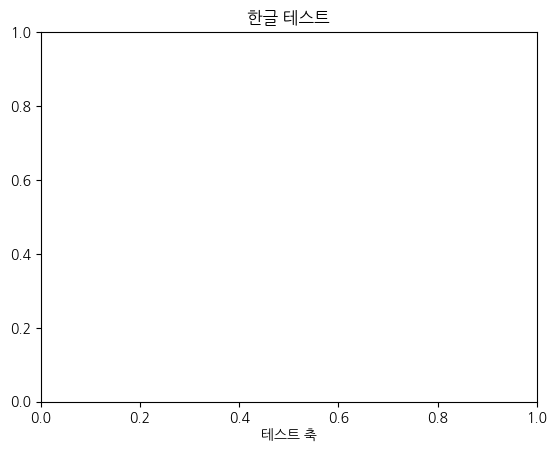

In [ ]:
from google.colab import drive, files
drive.mount('/content/drive')

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import shutil, os

uploaded = files.upload()
font_dst = '/usr/local/share/fonts/NanumGothic.ttf'
os.makedirs('/usr/local/share/fonts', exist_ok=True)
shutil.copy('NanumGothic.ttf', font_dst)

fm.fontManager.ttflist = [
    f for f in fm.fontManager.ttflist
    if '/content/drive' not in f.fname
]

fm.fontManager.addfont(font_dst)
mpl.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots()
ax.set_title('한글 테스트')
ax.set_xlabel('테스트 축')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import skew

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [ ]:
# 캐글(Kaggle)의 자전거 공유 수요 예측 대회 데이터를 활용 Regression 실습

#
bike_df = pd.read_csv('/content/drive/MyDrive/kwu/ML/data/bike_Sharing_Demand/train.csv')
print(bike_df.shape)
bike_df.head(3)

(10886, 12)


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32


In [ ]:
bike_df.info() # datetime 컬럼, 결측치, 수치형, 문자형 컬럼 구분

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [ ]:
# datetime 컬럼 파싱 + 시간 관련 피처 추출 + 트렌드 피처 생성
bike_df['datetime'] = bike_df.datetime.apply(pd.to_datetime)

bike_df['year'] = bike_df.datetime.apply(lambda x: x.year)
bike_df['month'] = bike_df.datetime.apply(lambda x: x.month)
bike_df['day'] = bike_df.datetime.apply(lambda x: x.day)
bike_df['hour'] = bike_df.datetime.apply(lambda x: x.hour)


In [ ]:
# 트렌드 피처 추가
# 모델이 '2012년은 수요가 더 높다'는 성장 트렌드를 못 학습하면 테스트셋을 지속적으로 과소 예측하게 됨
# 서비스 시작 시점(2011년 1월)부터 몇 번째 달인지를 나타내는 연속형 숫자
# -> '시간이 지날수록 수요가 선형적으로 증가'하는 트렌드를 표현
# month_index (경과 월 수)
# 2011년 1월 -> month_index = 1
# 2012년 1월 -> month_index = 13
# year(범주형)와의 차이: year는 2011, 2012 두 값만 각 연도의 평균 수준만 학습,
# month_index는 1~24 연속값이 있으면 월별 세밀한 성장 곡선 학습 가능
bike_df['month_index'] = (bike_df['year'] - 2011) * 12 + bike_df['month']

# time_index (전체 순서 번호)
# 데이터셋에서 시간 순서대로의 행 번호 (0, 1, 2, .... 10885)
# 시간이 흐를수록 수요가 증가하는 장기 트렌드를 가장 직접적으로 표현
# 선형 모델에서 특히 효과적: 계수 하나로 전체 성장 기울기를 학습
bike_df['time_index'] = np.arange(len(bike_df))

In [ ]:
bike_df.tail(3)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour,month_index,time_index
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168,2012,12,19,21,24,10883
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129,2012,12,19,22,24,10884
10885,2012-12-19 23:00:00,4,0,1,1,13.12,16.665,66,8.9981,4,84,88,2012,12,19,23,24,10885


In [ ]:
# 불필요한 컬럼 삭제
drop_columns = ['datetime', 'casual', 'registered'] # 비회원, 회원 대여 횟수 (count총 대여의 일부), 예측 시점에는 알 수 없는
bike_df.drop(drop_columns, axis=1, inplace=True) # bike_df 자체를 수정

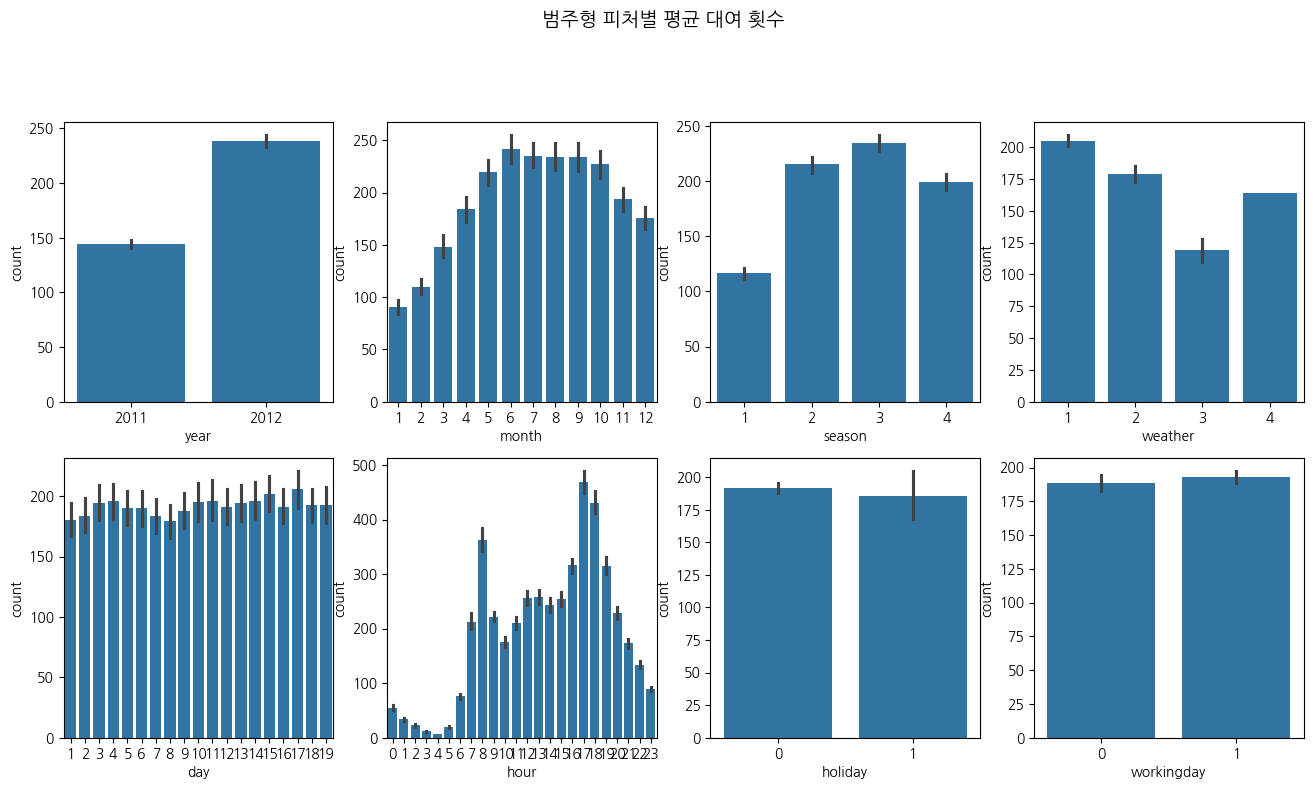

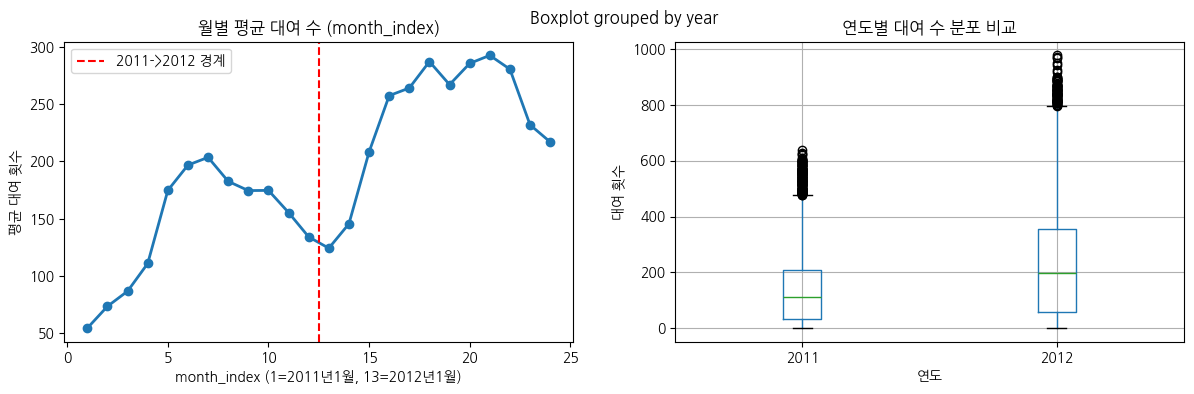

연도별 평균 대여 수:
year
2011    144.2
2012    238.6
Name: count, dtype: float64


In [ ]:
# 범주형 피처별 자전거 대여 수 시각화 (EDA), 연도별 수요 트렌드 확인
# 범주형 피처별 barplot
fig, axs = plt.subplots(figsize=(16, 8), ncols=4, nrows=2)
cat_features = ['year', 'month', 'season', 'weather',
                'day', 'hour', 'holiday', 'workingday']
for i, feature in enumerate(cat_features):
  row = int(i / 4)
  col = i % 4
  sns.barplot(x=feature, y='count', data=bike_df, ax=axs[row, col])
plt.suptitle('범주형 피처별 평균 대여 횟수', fontsize=14, y=1.02)
plt.tight_layout
plt.show()

# 트렌드 피처 시각화
fig, axes = plt.subplots(figsize=(14, 4), ncols=2)
# month_index별 평균 대여 수
monthly_avg = bike_df.groupby('month_index')['count'].mean()
axes[0].plot(monthly_avg.index, monthly_avg.values, marker='o', linewidth=2)
axes[0].set_title('월별 평균 대여 수 (month_index)')
axes[0].set_xlabel('month_index (1=2011년1월, 13=2012년1월)')
axes[0].set_ylabel('평균 대여 횟수')
axes[0].axvline(x=12.5, color='red', linestyle='--', label='2011->2012 경계')
axes[0].legend()

# 연도별 박스플롯: 2011 vs 2012 수요 수준 차이 확인
bike_df.boxplot(column='count', by='year', ax=axes[1])
axes[1].set_title('연도별 대여 수 분포 비교')
axes[1].set_xlabel('연도')
axes[1].set_ylabel('대여 횟수')
plt.tight_layout
plt.show()

print('연도별 평균 대여 수:')
print(bike_df.groupby('year')['count'].mean().round(1))


In [ ]:
# 평가 지표 함수 정의 (RMSLE, RMSE, MAE)
from sklearn.metrics import mean_squared_error, mean_absolute_error

# RMSLE (Root Mean Squared Log Error)
# 로그 스케일에서 오차를 측정하므로, 작은 값과 큰 값의 '상대적 오차'를 동등하게 평가
# '50% 틀렸다'는 것을 실제 값 크기에 관계없이 유사하게 패널티 부여
def rmsle(y, pred):
  log_y = np.log1p(y) # 실제값에 로그 변환
  log_pred = np.log1p(pred) # 예측값에 로그 변환
  squared_error = (log_y - log_pred) ** 2
  rmsle = np.sqrt(np.mean(squared_error))
  return rmsle


# RMSE (Root Mean Squared Error)
def rmse(y, pred):
  return np.sqrt(mean_squared_error(y, pred))
# 큰 오차를 제곱으로 더 크게 벌주므로 이상치에 민감, 원본 단위(대여 횟수)로 해석 가능

# 세 평가지표를 한 번에 출력
def evaluate_regr(y, pred):
  rmsle_val = rmsle(y, pred)
  rmse_val = rmse(y, pred)
  mae_val = mean_absolute_error(y, pred) # MAE (Mean Absolute Error): 절대 오차의 평균, 이상치에 가장 덜 민감한 지표
  print('RMSLE: {0:.3f}, RMSE: {1:.3F}, MAE: {2:.3F}'.format(
      rmsle_val, rmse_val, mae_val))

In [ ]:
# [Step 1] 시간순 80/20 분할 + 기본 LinearRegression -> Baseline_code
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import make_scorer

# 피처(X)와 타깃(y) 분리
y_target = bike_df['count']
X_features = bike_df.drop(['count'], axis=1, inplace=False)

# 시계열 데이터 분할: 시간 순서대로 80:20
split_idx = int(len(X_features) * 0.8)

X_train_full = X_features.iloc[:split_idx]
X_test       = X_features.iloc[split_idx:]
y_train_full = y_target.iloc[:split_idx]
y_test       = y_target.iloc[split_idx:]

print(f'전체 데이터 : {len(X_features)}행')
print(f'훈련셋 (80%) : {len(X_train_full)}행')
print(f'테스트셋(20%): {len(X_test)}행')
print('훈련셋 연도 분포:')
print(bike_df.iloc[:split_idx]['year'].value_counts().sort_index())
print('테스트셋 연도 분포:')
print(bike_df.iloc[split_idx:]['year'].value_counts().sort_index())
# 이 성능은 이후에 개선됩니다

전체 데이터 : 10886행
훈련셋 (80%) : 8708행
테스트셋(20%): 2178행
훈련셋 연도 분포:
year
2011    5422
2012    3286
Name: count, dtype: int64
테스트셋 연도 분포:
year
2012    2178
Name: count, dtype: int64


In [ ]:
# 기본 LinearRegression (로그 변환 없이) -> 기준선 확인
lr_reg = LinearRegression()
lr_reg.fit(X_train_full, y_train_full)
pred = lr_reg.predict(X_test)
evaluate_regr(y_test, pred)

RMSLE: 1.243, RMSE: 183.966, MAE: 141.547


In [ ]:
# 오차가 가장 큰 상위 5개 데이터 확인 (오류 분석)
def get_top_error_data(y_test, pred, n_tops=5):
  result_df = pd.DataFrame(y_test.values, columns=['real_count'])
  result_df['predicted_count'] = np.round(pred)
  result_df['diff'] = np.abs(
      result_df['real_count'] - result_df['predicted_count']
  )
  print(result_df.sort_values('diff', ascending=False)[:n_tops])

get_top_error_data(y_test, pred, n_tops=5)

      real_count  predicted_count   diff
1203         817            167.0  650.0
1227         834            188.0  646.0
1035         839            199.0  640.0
1179         835            206.0  629.0
867          809            190.0  619.0


<Axes: >

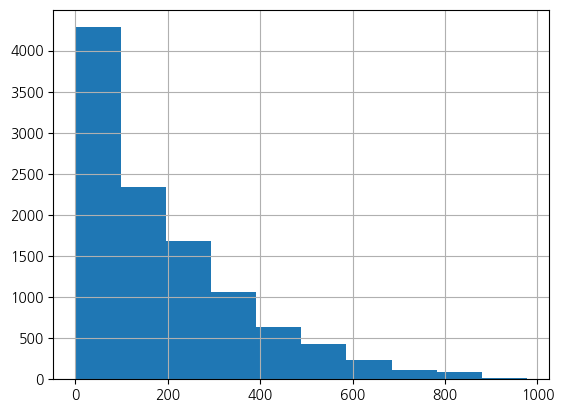

In [ ]:
# 타깃 변수(count)의 분포 확인 (로그 변환 전)
y_target.hist() #hist(): 히스토그램 출력

<Axes: >

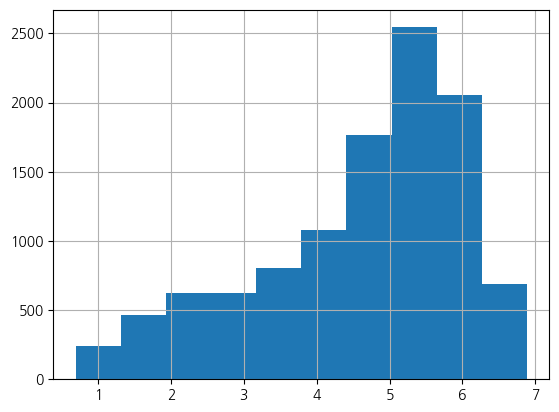

In [ ]:
# 로그 변환 후 분포 확인
y_log_transform = np.log1p(y_target)
y_log_transform.hist()

In [ ]:
# Step 2: 타깃 로그 변환 + TimeSeriesSplit 교차검증
y_target_log = np.log1p(y_target)
y_train_log_full = y_target_log.iloc[:split_idx]
y_test_log = y_target_log.iloc[split_idx:]

# 사이킷런 cross_val_score에는 RMSLE가 기본 제공되지 않으므로 make_score()로 직접 만들어야 함
def rmsle_log_target(y_true_log, y_pred_log):
  y_pred_clipped = np.maximum(y_pred_log, 0) # 음수일때 큰값 0 선택
  return np.sqrt(np.mean((y_true_log - y_pred_clipped) ** 2))

rmsle_scorer = make_scorer(rmsle_log_target, greater_is_better=False)
# 사용자 정의한 커스텀 스코어 함수를 scikit-learn의 교차 검증 및 모델 선택 도구와 호환되는 스코어러 객체로 변환

In [ ]:
# TimeSeriesSplit 교차검증
# n_splits=5 분할 구조 (훈련셋 기준):
#   fold 1: [■□□□□□] 학습 → [□■□□□□] 검증
#   fold 2: [■■□□□□] 학습 → [□□■□□□] 검증
#   fold 3: [■■■□□□] 학습 → [□□□■□□] 검증
#   fold 4: [■■■■□□] 학습 → [□□□□■□] 검증
#   fold 5: [■■■■■□] 학습 → [□□□□□■] 검증

tscv = TimeSeriesSplit(n_splits=5)
lr_reg = LinearRegression()

# RMSLE 교차검증
cv_rmsle = -1 * cross_val_score(
    lr_reg, X_train_full, y_train_log_full,
    cv = tscv, scoring=rmsle_scorer)

# RMSE 교차검증 (log 스케일)
cv_rmse = np.sqrt(-1 * cross_val_score(
    lr_reg, X_train_full, y_train_log_full,
    cv = tscv, scoring='neg_mean_squared_error'
))

print('TimeSeriesSplit 교차검증 - LinearRegression (로그 변환)')
print(f'{"":6} {"RMSE":>10} {"RMSE(log)":>10}')
for i, (r1, r2) in enumerate(zip(cv_rmsle, cv_rmse), 1):
  print(f'fold {i} {r1:>10.4f} {r2:>10.4f}')
print(f'평균 {cv_rmsle.mean():>10.4f} {cv_rmse.mean():>10.4f}')
print(f'std {cv_rmsle.std():>10.4f} {cv_rmse.std():>10.4f}' )

# 최종 평가: 전체 훈련셋 재학습 -> 테스트셋 평가
lr_reg.fit(X_train_full, y_train_log_full)
pred_log = lr_reg.predict(X_test)
y_test_exp = np.expm1(y_test_log) # 로그 변환된 값을 원래 스케일의 값으로 되돌리는 역할
pred_exp = np.expm1(np.maximum(pred_log, 0))
# np.expm1() 함수는 exp(x) - 1을 계산하는 넘파이(Numpy) 함수, exp(x)는 자연 상수 e를 x 제곱한

print('최종 테스트셋 평가 - LinearRegression (로그 변환)')
evaluate_regr(y_test_exp, pred_exp)

TimeSeriesSplit 교차검증 - LinearRegression (로그 변환)
             RMSE  RMSE(log)
fold 1     1.1416     1.1416
fold 2     0.9753     0.9753
fold 3     2.4224    11.1313
fold 4     1.1352     1.1352
fold 5     1.0114     1.0114
평균     1.3372     3.0789
std     0.5466     4.0267
최종 테스트셋 평가 - LinearRegression (로그 변환)
RMSLE: 1.013, RMSE: 208.313, MAE: 145.906


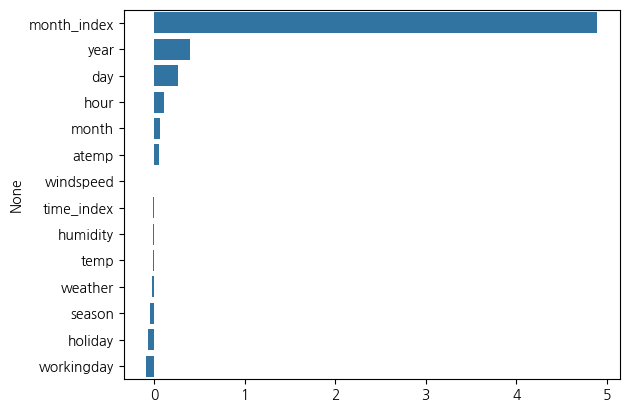

In [ ]:
# 회귀 계수 시각화 (피처 중요도 파악)
coef = pd.Series(lr_reg.coef_, index=X_features.columns) #.coef_: 학습된 선형 회귀의 회귀 계수 배열
coef
# 양수 계수: 해당 피처 증가 -> 대여 수 증가에 기여
# 음수 계수: 해당 피처 증가 -> 대여 수 감소에 기여
# 절대값이 클수록 해당 피처가 예측에 더 큰 영향
coef_sort = coef.sort_values(ascending=False)
sns.barplot(x=coef_sort.values, y=coef_sort.index)
plt.savefig('/content/drive/MyDrive/kwu/ML/data/log_transform.png', format='png', dpi=96, bbox_inches='tight')

In [ ]:
# Step 3: 원-핫 인코딩 + 트렌드 피처 적용
# 원-핫 인코딩 적용: 순서/크기 관계 없는 순수 범주형
# 수치형으로 유지: 연속적 의미가 있는 피처, year
X_features_ohe = pd.get_dummies(
    X_features,
    columns=['month', 'day', 'hour',
             'holiday', 'workingday', 'season', 'weather'])
print('원-핫 인코딩 전 피처 수 :', X_features.shape[1])
print('원-핫 인코딩 후 피처 수 :', X_features_ohe.shape[1])

원-핫 인코딩 전 피처 수 : 14
원-핫 인코딩 후 피처 수 : 74


In [ ]:
# Step 4: 선형 모델 3종 비교
# (LinearRegression, Ridge, Lasso)+ TimeSeriesSplit 교차검증 (RMSLE + RMSE)

# 원-핫 인코딩된 X로 시간순 분할
X_train_ohe = X_features_ohe.iloc[:split_idx]
X_test_ohe = X_features_ohe.iloc[split_idx:]
y_train_log_full = y_target_log.iloc[:split_idx]
y_test_log = y_target_log.iloc[split_idx:]

# 모델 평가 헬퍼 함수
def get_model_predict(model, X_train, X_test, y_train, y_test, is_expm1=False):
  model.fit(X_train, y_train)
  pred = model.predict(X_test)
  if is_expm1:
    y_test = np.expm1(y_test)
    pred = np.expm1(np.maximum(pred, 0))
  print(model.__class__.__name__)
  evaluate_regr(y_test, pred)

# 세 가지 선형 모델 생성
lr_reg = LinearRegression()
ridge_reg = Ridge(alpha=10)
lasso_reg = Lasso(alpha=0.01)

tscv = TimeSeriesSplit(n_splits=5)
print('TimeSeriesSplit 교차검증 결과 - 선형 모델 3종')
print(f'{"모델":<22} {"RMSLE 평균":>12} {"RMSLE std":>10} {"RMSE 평균":>10}')
for model in [lr_reg, ridge_reg, lasso_reg]:
  cv_rmsle = -1 * cross_val_score(
    model, X_train_ohe, y_train_log_full,
    cv=tscv, scoring=rmsle_scorer
  )
  cv_rmse = np.sqrt(-1 * cross_val_score(
      model, X_train_ohe, y_train_log_full,
      cv=tscv, scoring='neg_mean_squared_error'
  ))
  print(f' {model.__class__.__name__:<20}'
        f'{cv_rmsle.mean():>12.4f}'
        f'{cv_rmsle.std():>10.4f}'
        f'{cv_rmse.mean():>10.4f}')
# 최종 테스트셋 평가
print('최종 테스트셋 평가 - 선형 모델 3종')
for model in [lr_reg, ridge_reg, lasso_reg]:
  get_model_predict(model,
                      X_train_ohe, X_test_ohe,
                    y_train_log_full, y_test_log,
                    is_expm1=True)

# 교차검증 RMSLE std가 작을수록 -> fold마다 안정적인 모델
# 교차검증 RMSLE 과 테스트셋 RMSLE 비슷 -> 과적합 없이 일반화됨

TimeSeriesSplit 교차검증 결과 - 선형 모델 3종
모델                         RMSLE 평균  RMSLE std    RMSE 평균
 LinearRegression          0.9325    0.2254    0.9337
 Ridge                     0.6698    0.0393    0.6698
 Lasso                     0.6604    0.0341    0.6604
최종 테스트셋 평가 - 선형 모델 3종
LinearRegression
RMSLE: 0.572, RMSE: 121.846, MAE: 83.203
Ridge
RMSLE: 0.579, RMSE: 118.918, MAE: 82.525
Lasso
RMSLE: 0.616, RMSE: 137.806, MAE: 93.555


In [ ]:
# Step 5: 트리 기반 앙상블 모델 비교
# (RandomForest, GBM, XGBoost, LightGBM)+ TimeSeriesSplit 교차검증 (RMSLE + RMSE)
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# 4가지 앙상블 모델 생성

# TimeSeriesSplit 교차검증: RMSLE + RMSE

# 최종 테스트셋 평가